In [5]:
%pip install torch


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install sentence-transformers transformers


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy
import torch
from sentence_transformers import SentenceTransformer
import transformers
import warnings
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import os
import json
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.width', 1000)
print("✅ Libraries imported successfully! Environment is ready.")

✅ Libraries imported successfully! Environment is ready.


In [8]:
file_path = '../data/processed/preprocessed_employee_task_data.csv'
df = pd.read_csv(file_path)
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
print("--- Column Names & Data Types ---")
print(df.dtypes.to_string())
print("\n")
print("--- Missing-Value Summary ---")
missing_values = df.isnull().sum()
missing_filtered = missing_values[missing_values > 0]
if missing_filtered.empty:
    print("✅ No missing values found (excluding any intentionally left blank like deadlines).")
else:
    print(missing_filtered.to_string())
print("\n")
print("--- Unique Values for Key Columns ---")
key_columns = [
    'Employee_ID', 
    'Task_ID', 
    'Project_Name', 
    'Employee_Department', 
    'Employee_Job_Position', 
    'Task_Priority'
]
for col in key_columns:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} unique values")
print("\n")
print("--- First 5 Rows ---")
display(df.head())

Dataset Shape: 11,630 rows × 19 columns

--- Column Names & Data Types ---
Date                                            str
Task_ID                                         str
Task_Name                                       str
Work_Description                                str
Hours_Spent                                 float64
Project_Name                                    str
Employee_ID                                     str
Employee_Department                             str
Employee_Job_Position                           str
Task_Description                                str
FLAG_LEAKAGE_Timesheet_Work_Logs                str
Task_Priority                                   str
Estimated_Planned_Hours                     float64
FLAG_LEAKAGE_Actual_Hours_Spent             float64
FLAG_LEAKAGE_Timesheet_Logs_Count             int64
FLAG_LEAKAGE_Task_Stage                         str
Created_Date                                    str
Deadline_Date                            

,Date,Task_ID,Task_Name,Work_Description,Hours_Spent,Project_Name,Employee_ID,Employee_Department,Employee_Job_Position,Task_Description,FLAG_LEAKAGE_Timesheet_Work_Logs,Task_Priority,Estimated_Planned_Hours,FLAG_LEAKAGE_Actual_Hours_Spent,FLAG_LEAKAGE_Timesheet_Logs_Count,FLAG_LEAKAGE_Task_Stage,Created_Date,Deadline_Date,FLAG_LEAKAGE_All_Collaborating_Employees
0,2026-09-14,TSK-1640,odoo sh maintain,db backup and restore in test,0.25,Hovael Project,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),odoo sh maintain. work details: add addons t the server | get backup from live and restore in test.get backup test and send both to nadeesha | add qutation summary and test why it is not installin...,add addons t the server | get backup from live and restore in test.get backup test and send both to nadeesha | add qutation summary and test why it is not installing and install the basereport xls...,Low,0.0,14.25,27,Project Preparation,2026-02-05,NaN,W M I L Wijesinghe
1,2026-09-14,TSK-1881,odoo sh maintain,db backup and restore in test,0.25,Ceylon Eco Spices,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),odoo sh maintain. work details: add addon and test | get odoo sh live ackup and restore in test | add quick book.get from milanka | backup restore to test | add addons | add addons and get backup ...,add addon and test | get odoo sh live ackup and restore in test | add quick book.get from milanka | backup restore to test | add addons | add addons and get backup adn restore in live | add invent...,Low,0.0,6.50,13,Developments,2026-03-19,NaN,W M I L Wijesinghe
2,2026-09-14,TSK-182,odoo.sh maintaing,add addons,0.25,Mihiri Bakemart (Pvt)Ltd - Development,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),odoo.sh maintaing. work details: add all addon and build and test on the odoo sh | clean and refresh the odoosh | add addon and build thenew build and test th addons | add addon and test | add add...,add all addon and build and test on the odoo sh | clean and refresh the odoosh | add addon and build thenew build and test th addons | add addon and test | add addon and test addon witchanuka and ...,Low,0.0,40.75,29,Ongoing,2025-06-09,NaN,W M I L Wijesinghe
3,2026-09-14,TSK-2884,development meeting,/,0.00,Cygnus One,EMP-55,Colombo Branch,Project Manager,development meeting. work details: intern development hoveal project meeting | meeting milan and plan the developments | hovael meeting | sewinco development discussion | requirment discuss hovael...,"intern development hoveal project meeting | meeting milan and plan the developments | hovael meeting | sewinco development discussion | requirment discuss hovael,mihiri and steel mart | rfq app ch...",Low,0.0,9.42,13,Miscellaneous,2026-07-06,NaN,"W M I L Wijesinghe, K R V Dias, A R M S Madusanka, Malshi Jayanthi"
4,2026-09-14,TSK-405,other tasks (mention on description),get privillages to charith's new github account on odoo sh projects and the all repositories,0.50,Cygnus One,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),other tasks (mention on description). work details: self ssl setup on vps | preparing report list | richy sql table exporting | create material issue video clip | added anthonies domain | create g...,self ssl setup on vps | preparing report list | richy sql table exporting | create material issue video clip | added anthonies domain | create grn import template | landed cost | create demo datab...,Low,0.0,162.18,69,Miscellaneous,2025-07-14,NaN,"H.M.C.S Thilakarathna, Sadaruwan Bandara, L H P S S Pathirana, I G C Bandara, W M I L Wijesinghe, G L Sachini"


In [9]:
train_ratio = 0.6
test_ratio = 0.2
val_ratio = 0.2
train_df, temp_df = train_test_split(df, test_size=(test_ratio + val_ratio), random_state=42)
test_df, val_df = train_test_split(temp_df, test_size=(val_ratio / (test_ratio + val_ratio)), random_state=42)
print(f"Original dataset shape: {df.shape}")
print(f"Training set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"Validation set shape: {val_df.shape}")
output_dir = '../data/processed/split_datasets'
os.makedirs(output_dir, exist_ok=True)
train_df.to_csv(os.path.join(output_dir, 'train_dataset.csv'), index=False)
test_df.to_csv(os.path.join(output_dir, 'test_dataset.csv'), index=False)
val_df.to_csv(os.path.join(output_dir, 'val_dataset.csv'), index=False)
print(f"\nDatasets saved to: {output_dir}")

Original dataset shape: (11630, 19)
Training set shape: (6978, 19)
Test set shape: (2326, 19)
Validation set shape: (2326, 19)

Datasets saved to: ../data/processed/split_datasets


In [10]:
TARGET = "Employee_ID"
print(f"🎯 Model Objective: Recommend/rank '{TARGET}' for newly created tasks.\n")
leakage_columns = [
    "Actual_Hours_Spent",
    "Timesheet_Work_Logs",
    "Timesheet_Logs_Count",
    "Task_Stage",
    "All_Collaborating_Employees"
]
print("⚠️ Leakage columns identified and isolated (Not deleted).")
post_assignment_features = leakage_columns + ["Work_Description"]

🎯 Model Objective: Recommend/rank 'Employee_ID' for newly created tasks.

⚠️ Leakage columns identified and isolated (Not deleted).


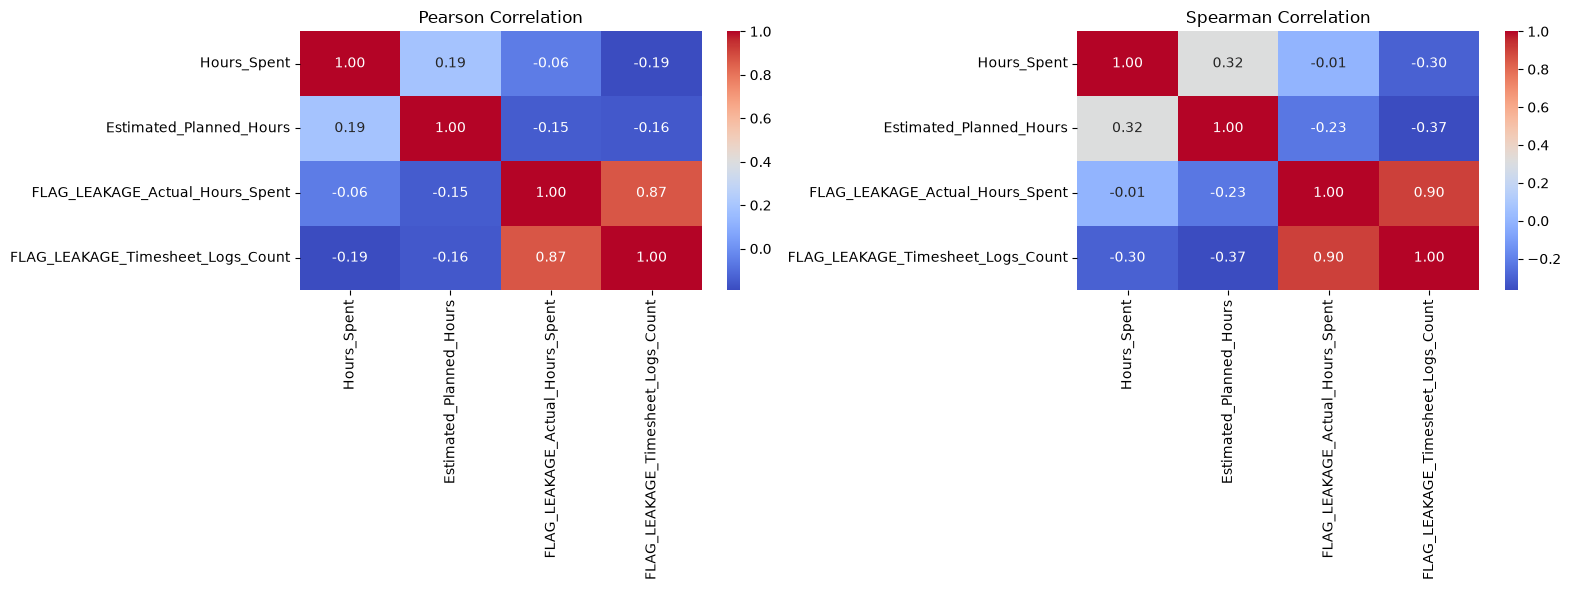

Highly Correlated Numerical Pairs (Pearson | >= 0.70):
 - FLAG_LEAKAGE_Actual_Hours_Spent & FLAG_LEAKAGE_Timesheet_Logs_Count: 0.870

Highly Correlated Numerical Pairs (Spearman | >= 0.70):
 - FLAG_LEAKAGE_Actual_Hours_Spent & FLAG_LEAKAGE_Timesheet_Logs_Count: 0.904

--- Mutual Information Scores (Target: Employee_ID) ---


,Feature,Mutual_Information
4,Employee_Job_Position,2.521481
1,Task_Name,2.311665
3,Employee_Department,1.311402
0,Project_Name,1.230825
2,Task_Priority,0.031076



--- Target Distribution (Employee_ID) ---
Total Unique Employees: 43
Average Tasks per Employee: 145.38
Median Tasks per Employee: 70.50
Most Frequently Assigned: EMP-5 (611 tasks)
Least Frequently Assigned: EMP-67 (1 tasks)

Top 10 Employees by Assignment Count:


,Task_Count,count
0,EMP-5,611
1,EMP-10,582
2,EMP-11,565
3,EMP-17,374
4,EMP-4,322
5,EMP-12,319
6,EMP-16,310
7,EMP-7,301
8,EMP-27,289
9,EMP-22,278



Bottom 5 Employees by Assignment Count:


,Task_Count,count
0,EMP-52,9
1,EMP-59,7
2,EMP-24,6
3,EMP-25,5
4,EMP-67,1


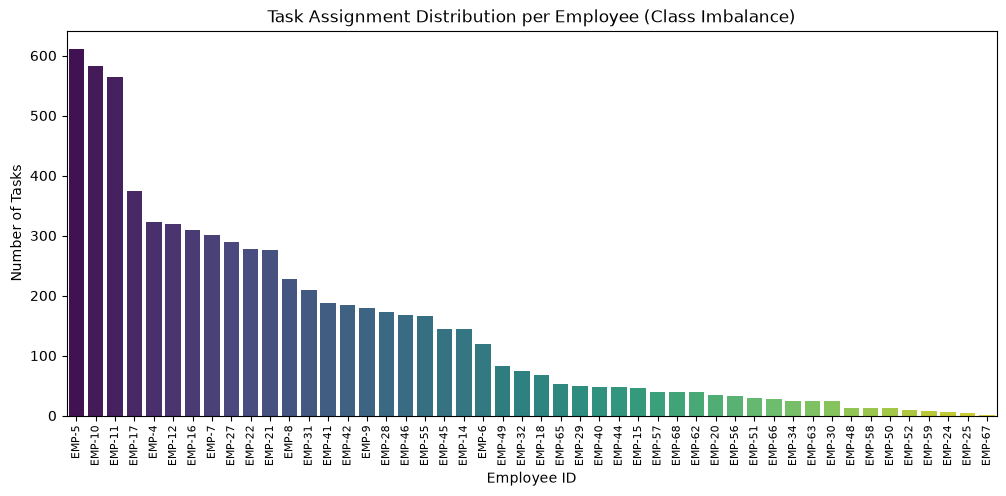

In [11]:
numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
if 'Employee_ID' in numerical_cols: numerical_cols.remove('Employee_ID')
if 'Task_ID' in numerical_cols: numerical_cols.remove('Task_ID')
pearson_corr = train_df[numerical_cols].corr(method='pearson')
spearman_corr = train_df[numerical_cols].corr(method='spearman')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title("Pearson Correlation")
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title("Spearman Correlation")
plt.tight_layout()
plt.show()
def get_highly_correlated_pairs(corr_matrix, threshold=0.70):
    pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) >= threshold:
                pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))
    return pairs
print("Highly Correlated Numerical Pairs (Pearson | >= 0.70):")
pearson_pairs = get_highly_correlated_pairs(pearson_corr)
for p in pearson_pairs: print(f" - {p[0]} & {p[1]}: {p[2]:.3f}")
print("\nHighly Correlated Numerical Pairs (Spearman | >= 0.70):")
spearman_pairs = get_highly_correlated_pairs(spearman_corr)
for p in spearman_pairs: print(f" - {p[0]} & {p[1]}: {p[2]:.3f}")
from sklearn.metrics import mutual_info_score
print("\n--- Mutual Information Scores (Target: Employee_ID) ---")
cat_features = [
    'Project_Name', 
    'Task_Name', 
    'Task_Priority', 
    'Employee_Department', 
    'Employee_Job_Position'
]
mi_scores = []
for col in cat_features:
    if col in train_df.columns:
        col_data = train_df[col].fillna("Unknown").astype(str)
        target_data = train_df['Employee_ID'].astype(str)
        mi = mutual_info_score(col_data, target_data)
        mi_scores.append({'Feature': col, 'Mutual_Information': mi})
mi_train_df = pd.DataFrame(mi_scores).sort_values(by='Mutual_Information', ascending=False)
display(mi_train_df)
print("\n--- Target Distribution (Employee_ID) ---")
employee_counts = train_df['Employee_ID'].value_counts()
print(f"Total Unique Employees: {employee_counts.nunique()}")
print(f"Average Tasks per Employee: {employee_counts.mean():.2f}")
print(f"Median Tasks per Employee: {employee_counts.median():.2f}")
print(f"Most Frequently Assigned: {employee_counts.index[0]} ({employee_counts.iloc[0]} tasks)")
print(f"Least Frequently Assigned: {employee_counts.index[-1]} ({employee_counts.iloc[-1]} tasks)\n")
print("Top 10 Employees by Assignment Count:")
display(employee_counts.head(10).reset_index().rename(columns={'index': 'Employee_ID', 'Employee_ID': 'Task_Count'}))
print("\nBottom 5 Employees by Assignment Count:")
display(employee_counts.tail(5).reset_index().rename(columns={'index': 'Employee_ID', 'Employee_ID': 'Task_Count'}))
plt.figure(figsize=(12, 5))
sns.barplot(x=employee_counts.index, y=employee_counts.values, palette='viridis')
plt.title("Task Assignment Distribution per Employee (Class Imbalance)")
plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Number of Tasks")
plt.xlabel("Employee ID")
plt.show()

In [12]:
train_df["Task_Text"] = (
    train_df["Task_Name"].astype(str).fillna("") + " " +
    train_df["Task_Description"].astype(str).fillna("")
).str.strip()
train_df["Task_Text_Length"] = train_df["Task_Text"].str.len()
train_df["Task_Word_Count"] = train_df["Task_Text"].str.split().str.len()
train_df["Task_Description_Length"] = train_df["Task_Description"].astype(str).fillna("").str.len()
train_df["Task_Name_Length"] = train_df["Task_Name"].astype(str).fillna("").str.len()
train_df["Has_Task_Description"] = (train_df["Task_Description_Length"] > 0).astype(int)
print("--- New Deterministic Text Features ---")
display(train_df[["Task_Name", "Task_Text", "Task_Text_Length", "Task_Word_Count", "Has_Task_Description"]].head())

--- New Deterministic Text Features ---


,Task_Name,Task_Text,Task_Text_Length,Task_Word_Count,Has_Task_Description
6713,post costing,post costing post costing. work details: post model creation | post import costing | post costing cost calculation fix | search view and filters,144,24,1
10144,canteen request send to production manager,canteen request send to production manager canteen request send to production manager. work details: create the canteen modal | create the view and implement the view manufacturing summary | write...,354,58,1
877,mainly from staff number,mainly from staff number mainly from staff number. work details: built name_search override on hr.employee to search name + staff no + epf no across all modules | extended employees search view — ...,446,71,1
9451,system support,"system support system support. work details: meeting with mr. vibeeshan | system support | support | support and setup tax | support mr. vibeeshana | uat, user account setup, database testing | ho...",313,53,1
196,odoo sh maintain,odoo sh maintain odoo sh maintain. work details: add addons t the server | get backup from live and restore in test.get backup test and send both to nadeesha | add qutation summary and test why it...,1014,206,1


In [13]:
date_cols = ['Created_Date', 'Deadline_Date']
for col in date_cols:
    if col in train_df.columns:
        train_df[col] = pd.to_datetime(train_df[col], errors='coerce')
if 'Created_Date' in train_df.columns:
    train_df['Created_Year'] = train_df['Created_Date'].dt.year
    train_df['Created_Month'] = train_df['Created_Date'].dt.month
    train_df['Created_DayOfWeek'] = train_df['Created_Date'].dt.dayofweek
    train_df['Created_Quarter'] = train_df['Created_Date'].dt.quarter
if 'Created_Date' in train_df.columns and 'Deadline_Date' in train_df.columns:
    train_df['Days_To_Deadline'] = (train_df['Deadline_Date'] - train_df['Created_Date']).dt.days
    train_df['Has_Deadline'] = train_df['Deadline_Date'].notnull().astype(int)
print("--- New Date-Based Features ---")
display(train_df[['Created_Date', 'Created_Month', 'Created_DayOfWeek', 'Deadline_Date', 'Days_To_Deadline', 'Has_Deadline']].head())

--- New Date-Based Features ---


,Created_Date,Created_Month,Created_DayOfWeek,Deadline_Date,Days_To_Deadline,Has_Deadline
6713,2026-01-02,1,4,NaT,NaN,0
10144,2025-08-27,8,2,NaT,NaN,0
877,2026-08-05,8,2,NaT,NaN,0
9451,2025-09-30,9,1,NaT,NaN,0
196,2026-02-05,2,3,NaT,NaN,0


In [14]:
train_df['Planned_Hours_Log'] = np.log1p(train_df['Estimated_Planned_Hours'])
bins = [-1, 8, 40, float('inf')]
labels = ['Small', 'Medium', 'Large']
train_df['Planned_Task_Size'] = pd.cut(train_df['Estimated_Planned_Hours'], bins=bins, labels=labels)
print("--- Planned-Hours Features ---")
display(train_df[['Estimated_Planned_Hours', 'Planned_Hours_Log', 'Planned_Task_Size']].head(10))

--- Planned-Hours Features ---


,Estimated_Planned_Hours,Planned_Hours_Log,Planned_Task_Size
6713,32.0,3.496508,Medium
10144,24.0,3.218876,Medium
877,24.0,3.218876,Medium
9451,0.0,0.000000,Small
196,0.0,0.000000,Small
11337,0.0,0.000000,Small
3383,0.0,0.000000,Small
4379,32.0,3.496508,Medium
7910,0.0,0.000000,Small
8348,0.0,0.000000,Small


In [15]:
print("Loading sentence-transformers/all-MiniLM-L6-v2...")
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
skill_taxonomy = {
    "Odoo ERP Development": "Odoo ERP development, addons, github, and technical maintenance",
    "Database Management": "Database management, SQL, db backup, data import, and restore",
    "Server Administration": "Server administration, VPS setup, SSL, and deployment",
    "Project Management": "Project management, meetings, scrum, and planning",
    "Software Testing": "Software testing, UAT session, quality assurance, and bug fixing",
    "Web Development": "Web development, frontend, and backend coding",
    "Client & Functional Support": "Client support, functional support, live support, and troubleshooting",
    "Documentation": "Preparing reports, blueprints, documentation, and lists",
    "Training & Mentorship": "Intern training, presale training, conducting training sessions, and explaining processes"
}
skill_names = list(skill_taxonomy.keys())
skill_descriptions = list(skill_taxonomy.values())
print("Embedding the skill taxonomy...")
skill_embeddings = model.encode(skill_descriptions, convert_to_numpy=True)
print(f"Embedding {len(train_df)} task descriptions... (This will take ~15-20 minutes on CPU)")
task_texts = train_df['Task_Text'].astype(str).fillna("").tolist()
task_embeddings = model.encode(task_texts, convert_to_numpy=True, show_progress_bar=True)
print("Calculating semantic similarities...")
similarities = cosine_similarity(task_embeddings, skill_embeddings)
THRESHOLD = 0.30  
extracted_skills_list = []
skill_counts = []
debug_details = []
for i in range(len(task_texts)):
    task_sims = similarities[i]
    matched_indices = np.where(task_sims >= THRESHOLD)[0]
    if len(matched_indices) > 0:
        sorted_matches = sorted(matched_indices, key=lambda idx: task_sims[idx], reverse=True)
        skills_str = " | ".join([skill_names[idx] for idx in sorted_matches])
        debug_str = " | ".join([f"{skill_names[idx]} ({task_sims[idx]:.2f})" for idx in sorted_matches])
    else:
        skills_str = "Uncategorized"
        debug_str = "None"
    extracted_skills_list.append(skills_str)
    skill_counts.append(len(matched_indices))
    debug_details.append(debug_str)
train_df['Task_Skills'] = extracted_skills_list
train_df['Task_Skill_Count'] = skill_counts
train_df['Debug_Skill_Scores'] = debug_details
print("\n--- Manual Review: Semantic Skill Extraction ---")
print(f"Threshold used: {THRESHOLD}\n")
print(f"Total 'Uncategorized' tasks: {(train_df['Task_Skills'] == 'Uncategorized').sum()}")
sample_review = train_df[['Task_Text', 'Task_Skills', 'Debug_Skill_Scores']].sample(30, random_state=42)
with pd.option_context('display.max_colwidth', None):
    display(sample_review)

Loading sentence-transformers/all-MiniLM-L6-v2...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1272.86it/s]


Embedding the skill taxonomy...
Embedding 6978 task descriptions... (This will take ~15-20 minutes on CPU)


Batches: 100%|██████████| 219/219 [06:50<00:00,  1.87s/it]


Calculating semantic similarities...

--- Manual Review: Semantic Skill Extraction ---
Threshold used: 0.3

Total 'Uncategorized' tasks: 1576


Task_Text  \
3278                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [16]:
print("     PART 10: EMPLOYEE SKILL PROFILES")

print("⚠️ Anti-Leakage Check: Profiles are being generated using TRAINING DATA ONLY (train_df).")
print("Validation and test records are strictly excluded from these historical profiles.\n")

historical_data = train_df[['Employee_ID', 'Task_Skills']].copy()

historical_data['Skill_List'] = historical_data['Task_Skills'].astype(str).str.split(' | ')

exploded_skills = historical_data.explode('Skill_List')

exploded_skills = exploded_skills[exploded_skills['Skill_List'] != 'Uncategorized']

employee_profiles = exploded_skills.groupby('Employee_ID')['Skill_List'].unique().reset_index()

employee_profiles['Historical_Skills'] = employee_profiles['Skill_List'].apply(lambda x: ' | '.join(x))
employee_profiles.drop(columns=['Skill_List'], inplace=True)

print("--- Employee Skill Profiles (Sample) ---")
display(employee_profiles.head(10))


     PART 10: EMPLOYEE SKILL PROFILES
⚠️ Anti-Leakage Check: Profiles are being generated using TRAINING DATA ONLY (train_df).
Validation and test records are strictly excluded from these historical profiles.

--- Employee Skill Profiles (Sample) ---


,Employee_ID,Historical_Skills
0,EMP-10,Odoo | ERP | Development | | | Documentation | Training | & | Mentorship | Software | Testing | Client | Functional | Support | Project | Management
1,EMP-11,Odoo | ERP | Development | Documentation | | | Project | Management | Training | & | Mentorship | Client | Functional | Support | Software | Testing | Database | Server | Administration
2,EMP-12,Client | & | Functional | Support | | | Documentation | Odoo | ERP | Development | Software | Testing | Database | Management | Server | Administration | Training | Mentorship | Project
3,EMP-14,Software | Testing | | | Project | Management | Odoo | ERP | Development | Web | Documentation | Database | Client | & | Functional | Support | Training | Mentorship | Server | Administration
4,EMP-15,Documentation | Project | Management | | | Odoo | ERP | Development | Client | & | Functional | Support
5,EMP-16,Client | & | Functional | Support | | | Documentation | Odoo | ERP | Development | Project | Management | Software | Testing | Training | Mentorship | Database
6,EMP-17,Client | & | Functional | Support | | | Software | Testing | Odoo | ERP | Development | Documentation | Training | Mentorship | Project | Management | Database | Server | Administration
7,EMP-18,Database | Management | Project | Documentation | | | Odoo | ERP | Development | Software | Testing | Training | & | Mentorship | Client | Functional | Support
8,EMP-20,Software | Testing | Project | Management | | | Documentation | Database | Odoo | ERP | Development | Training | & | Mentorship | Server | Administration | Client | Functional | Support
9,EMP-21,Project | Management | | | Documentation | Odoo | ERP | Development | Client | & | Functional | Support | Training | Mentorship | Software | Testing


In [17]:
project_task_counts = train_df['Project_Name'].value_counts().reset_index()
project_task_counts.columns = ['Project_Name', 'Project_Task_Count_Train']

train_df = train_df.merge(project_task_counts, on='Project_Name', how='left')

project_complexity = train_df.groupby('Project_Name')['Task_Skill_Count'].mean().reset_index()
project_complexity.columns = ['Project_Name', 'Project_Avg_Skill_Count_Train']

train_df = train_df.merge(project_complexity, on='Project_Name', how='left')

project_hours = train_df.groupby('Project_Name')['Estimated_Planned_Hours'].mean().reset_index()
project_hours.columns = ['Project_Name', 'Project_Avg_Planned_Hours_Train']

train_df = train_df.merge(project_hours, on='Project_Name', how='left')

display(train_df[['Project_Name', 'Project_Task_Count_Train', 'Project_Avg_Skill_Count_Train', 'Project_Avg_Planned_Hours_Train']].head(10))

,Project_Name,Project_Task_Count_Train,Project_Avg_Skill_Count_Train,Project_Avg_Planned_Hours_Train
0,Hovael Project,265,0.800000,23.973585
1,Mihiri Bakemart (Pvt)Ltd - Development,162,0.500000,18.777778
2,Hovael Project,265,0.800000,23.973585
3,Pioneer Implementation,87,2.034483,0.000000
4,Hovael Project,265,0.800000,23.973585
5,Cygnus One,2060,2.200000,2.320146
6,Cold Bavarage - Go Live,41,1.829268,5.463415
7,S00196 -Sewinco,421,1.624703,19.532067
8,Milanka Investment - Odoo 18 Implementation,252,1.420635,28.869048
9,Richi Dairies Lanka (Pvt) Ltd Implementation,93,2.376344,2.473118


In [20]:
output_dir = "/home/chandima-bandara/Desktop/intelligent-employee-task-allocation/data/processed/split_datasets"
os.makedirs(output_dir, exist_ok=True)

leakage_and_excluded = [
    "Actual_Hours_Spent",
    "Timesheet_Work_Logs",
    "Timesheet_Logs_Count",
    "Task_Stage",
    "All_Collaborating_Employees",
    "Work_Description",
    "Employee_Name"
]

final_train_df = train_df.drop(columns=[col for col in leakage_and_excluded if col in train_df.columns])

dataset_path = os.path.join(output_dir, "feature_engineered_train_dataset.csv")
final_train_df.to_csv(dataset_path, index=False)

taxonomy_df = pd.DataFrame({
    "Skill_Name": skill_names,
    "Skill_Description": skill_descriptions
})
taxonomy_path = os.path.join(output_dir, "skill_taxonomy.csv")
taxonomy_df.to_csv(taxonomy_path, index=False)

metadata = {
    "huggingface_model": "sentence-transformers/all-MiniLM-L6-v2",
    "embedding_dimensions": 384,
    "similarity_threshold": 0.30
}
metadata_path = os.path.join(output_dir, "model_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"✅ Final dataset saved to: {dataset_path}")
print(f"✅ Taxonomy saved to: {taxonomy_path}")
print(f"✅ Metadata saved to: {metadata_path}")
display(final_train_df.head())

✅ Final dataset saved to: /home/chandima-bandara/Desktop/intelligent-employee-task-allocation/data/processed/split_datasets/feature_engineered_train_dataset.csv
✅ Taxonomy saved to: /home/chandima-bandara/Desktop/intelligent-employee-task-allocation/data/processed/split_datasets/skill_taxonomy.csv
✅ Metadata saved to: /home/chandima-bandara/Desktop/intelligent-employee-task-allocation/data/processed/split_datasets/model_metadata.json


,Date,Task_ID,Task_Name,Hours_Spent,Project_Name,Employee_ID,Employee_Department,Employee_Job_Position,Task_Description,FLAG_LEAKAGE_Timesheet_Work_Logs,Task_Priority,Estimated_Planned_Hours,FLAG_LEAKAGE_Actual_Hours_Spent,FLAG_LEAKAGE_Timesheet_Logs_Count,FLAG_LEAKAGE_Task_Stage,Created_Date,Deadline_Date,FLAG_LEAKAGE_All_Collaborating_Employees,Task_Text,Task_Text_Length,Task_Word_Count,Task_Description_Length,Task_Name_Length,Has_Task_Description,Created_Year,Created_Month,Created_DayOfWeek,Created_Quarter,Days_To_Deadline,Has_Deadline,Planned_Hours_Log,Planned_Task_Size,Task_Skills,Task_Skill_Count,Debug_Skill_Scores,Project_Task_Count_Train,Project_Avg_Skill_Count_Train,Project_Avg_Planned_Hours_Train
0,2026-01-20,TSK-1444,post costing,8.0,Hovael Project,EMP-7,Research And Development (R&D),Team Lead - Research And Development (R&D),post costing. work details: post model creation | post import costing | post costing cost calculation fix | search view and filters,post model creation | post import costing | post costing cost calculation fix | search view and filters,Low,32.0,32.00,4,Project Preparation,2026-01-02,NaT,L H P S S Pathirana,post costing post costing. work details: post model creation | post import costing | post costing cost calculation fix | search view and filters,144,24,131,12,1,2026,1,4,1,NaN,0,3.496508,Medium,Documentation,1,Documentation (0.33),265,0.800000,23.973585
1,2025-08-28,TSK-563,canteen request send to production manager,6.5,Mihiri Bakemart (Pvt)Ltd - Development,EMP-11,Research And Development (R&D),Team Lead - Research And Development (R&D),canteen request send to production manager. work details: create the canteen modal | create the view and implement the view manufacturing summary | write the data in the manufacturing viewer and w...,create the canteen modal | create the view and implement the view manufacturing summary | write the data in the manufacturing viewer and write logic to pass the data into delivery modal | create d...,Low,24.0,20.50,4,Ongoing,2025-08-27,NaT,W M I L Wijesinghe,canteen request send to production manager canteen request send to production manager. work details: create the canteen modal | create the view and implement the view manufacturing summary | write...,354,58,311,42,1,2025,8,2,3,NaN,0,3.218876,Medium,Uncategorized,0,None,162,0.500000,18.777778
2,2026-08-12,TSK-3099,mainly from staff number,8.0,Hovael Project,EMP-10,Research And Development (R&D),Associate Software Engineer,mainly from staff number. work details: built name_search override on hr.employee to search name + staff no + epf no across all modules | extended employees search view — widened default quick-sea...,"built name_search override on hr.employee to search name + staff no + epf no across all modules | extended employees search view — widened default quick-search field, added dedicated ""staff no"" / ...",Low,24.0,24.00,3,In-Development,2026-08-05,NaT,M H R Chandrasoma,mainly from staff number mainly from staff number. work details: built name_search override on hr.employee to search name + staff no + epf no across all modules | extended employees search view — ...,446,71,421,24,1,2026,8,2,3,NaN,0,3.218876,Medium,Uncategorized,0,None,265,0.800000,23.973585
3,2025-09-29,TSK-833,system support,1.0,Pioneer Implementation,EMP-17,Business Solution,Odoo Functional Consultant,"system support. work details: meeting with mr. vibeeshan | system support | support | support and setup tax | support mr. vibeeshana | uat, user account setup, database testing | how to identify i...","meeting with mr. vibeeshan | system support | support | support and setup tax | support mr. vibeeshana | uat, user account setup, database testing | how to identify income in system | meeting with...",Low,0.0,34.00,24,System Study,2025-09-30,NaT,G L Sachini,"system support system support. work details: meeting with mr. vibeeshan | system support | support | support and setup tax | support mr. vibeeshana | uat, user account setup, da

In [21]:
print("     PART 16: FINAL DATASET VALIDATION")

print(f"Final shape: {final_train_df.shape}\n")

print(f"Duplicate rows: {final_train_df.duplicated().sum()}\n")

missing_vals = final_train_df.isnull().sum()
missing_filtered = missing_vals[missing_vals > 0]
print("Missing values:")
print(missing_filtered.to_string() if not missing_filtered.empty else "None")

print("\nTarget distribution (Top 5 Employees):")
print(final_train_df['Employee_ID'].value_counts().head().to_string())

print(f"\nNumber of extracted skills in taxonomy: {len(skill_names)}")
skill_columns = [col for col in final_train_df.columns if col.startswith('Skill_')]
print(f"Number of multi-hot skill columns present: {len(skill_columns)}\n")

print("Example Task_Text values:")
print(final_train_df['Task_Text'].head(3).to_string())

print("\nExample Task_Skills values:")
print(final_train_df['Task_Skills'].head(3).to_string())

print("\n--- Excluded Leakage Columns ---")
for col in leakage_and_excluded:
    print(f"- {col}")

print("\n--- Final Column List (Intended for Modelling) ---")
for col in final_train_df.columns:
    print(f"- {col}")

     PART 16: FINAL DATASET VALIDATION
Final shape: (6978, 38)

Duplicate rows: 238

Missing values:
FLAG_LEAKAGE_Timesheet_Work_Logs      44
Deadline_Date                       6116
Days_To_Deadline                    6116

Target distribution (Top 5 Employees):
Employee_ID
EMP-5     611
EMP-10    582
EMP-11    565
EMP-17    374
EMP-4     322

Number of extracted skills in taxonomy: 9
Number of multi-hot skill columns present: 0

Example Task_Text values:
0                                                           post costing post costing. work details: post model creation | post import costing | post costing cost calculation fix | search view and filters
1    canteen request send to production manager canteen request send to production manager. work details: create the canteen modal | create the view and implement the view manufacturing summary | write...
2    mainly from staff number mainly from staff number. work details: built name_search override on hr.employee to search name + 